<a href="https://colab.research.google.com/github/NicGal-1925/streaming-recommendation-system/blob/main/03_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Streaming Recommendation System

## Exploratory Data Analysis

This notebook explores user rating behavior, movie popularity, and movie metadata in the MovieLens Latest Small dataset.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import zipfile
import pandas as pd

In [3]:
zip_path = "/content/drive/MyDrive/Colab Notebooks/streaming-recommendation-system/data/ml-latest-small.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/data")

In [4]:
ratings = pd.read_csv("/content/data/ml-latest-small/ratings.csv")
movies = pd.read_csv("/content/data/ml-latest-small/movies.csv")

## Rating Distribution

Examine how frequently each rating value appears in the dataset.

In [5]:
ratings["rating"].value_counts()

,count
rating,
4.0,26818
3.0,20047
5.0,13211
3.5,13136
4.5,8551
2.0,7551
2.5,5550
1.0,2811
1.5,1791


In [6]:
ratings["rating"].value_counts().sort_index()

,count
rating,
0.5,1370
1.0,2811
1.5,1791
2.0,7551
2.5,5550
3.0,20047
3.5,13136
4.0,26818
4.5,8551


In [7]:
ratings["rating"].value_counts(normalize=True).sort_index()

,proportion
rating,
0.5,0.013586
1.0,0.027877
1.5,0.017762
2.0,0.074884
2.5,0.055040
3.0,0.198808
3.5,0.130271
4.0,0.265957
4.5,0.084801


In [8]:
ratings["rating"].value_counts(normalize=True).sort_index() * 100

,proportion
rating,
0.5,1.358642
1.0,2.787695
1.5,1.776151
2.0,7.488397
2.5,5.503987
3.0,19.880797
3.5,13.027093
4.0,26.595660
4.5,8.480106


In [9]:
ratings["rating"].mean()
ratings["rating"].median()

3.5

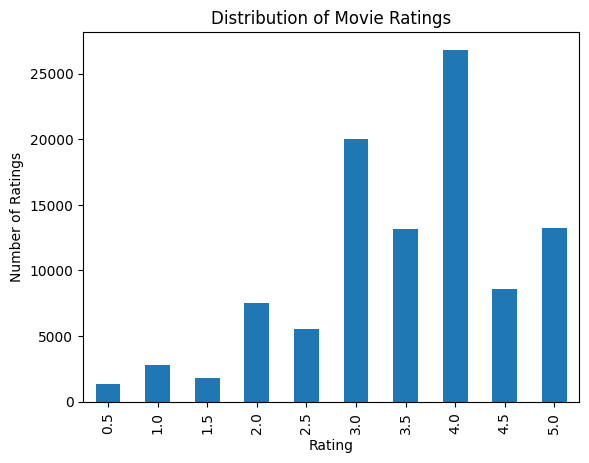

In [10]:
import matplotlib.pyplot as plt

ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")
plt.show()

### Observation

1. The most repeated rating is 4.0.
2. Low ratings are the least common than higher ratings.
3. The ratings greater than or equal to 4 add up to approximattely 48.18% for the liked movies, which leaves roughly 52% as not liked. This is a balanced distribution.

## Movie Popularity

Examine how many ratings each movie has received to identify the most frequently rated movies.

In [11]:
movie_rating_counts = ratings.groupby("movieId").size()

In [12]:
movie_rating_counts.head() #Group all rows belonging to the same movie, then count how many rating rows each movie has.

,0
movieId,
1,215
2,110
3,52
4,7
5,49


In [13]:
movie_rating_counts.sort_values(ascending=False).head(10) #Show the most rated movies, regardless of which rating they got.

,0
movieId,
356,329
318,317
296,307
593,279
2571,278
260,251
480,238
110,237
589,224


In [14]:
movie_rating_counts = movie_rating_counts.reset_index(name="rating_count")

In [15]:
movie_popularity = movies.merge(
    movie_rating_counts,
    on="movieId"
)

In [16]:
movie_popularity.head()

,movieId,title,genres,rating_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215
1,2,Jumanji (1995),Adventure|Children|Fantasy,110
2,3,Grumpier Old Men (1995),Comedy|Romance,52
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,7
4,5,Father of the Bride Part II (1995),Comedy,49


In [17]:
movie_popularity.sort_values(
    "rating_count",
    ascending=False
).head(10) #10 most frequently rated movies.

,movieId,title,genres,rating_count
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307
510,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279
1938,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278
224,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251
418,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,238
97,110,Braveheart (1995),Action|Drama|War,237
507,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,224
461,527,Schindler's List (1993),Drama|War,220


## Average Movie Ratings

Examine the average rating received by each movie.

In [18]:
movie_average_ratings = ratings.groupby("movieId")["rating"].mean()
movie_average_ratings.head()

,rating
movieId,
1,3.920930
2,3.431818
3,3.259615
4,2.357143
5,3.071429


In [19]:
movie_average_ratings = movie_average_ratings.reset_index(
    name="average_rating"
) #turn this series into a dataframe.
movie_average_ratings.head()

,movieId,average_rating
0,1,3.920930
1,2,3.431818
2,3,3.259615
3,4,2.357143
4,5,3.071429


In [20]:
movie_quality = movies.merge(
    movie_average_ratings,
    on="movieId"
) #merge with the movie titles
movie_quality.head()

,movieId,title,genres,average_rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.920930
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.431818
2,3,Grumpier Old Men (1995),Comedy|Romance,3.259615
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.357143
4,5,Father of the Bride Part II (1995),Comedy,3.071429


In [21]:
movie_quality.sort_values(
    "average_rating",
    ascending=False
).head(10) #sort by highest average (relative top 10)

,movieId,title,genres,average_rating
9693,187717,Won't You Be My Neighbor? (2018),Documentary,5.0
4667,6983,Jane Eyre (1944),Drama|Romance,5.0
3802,5328,Rain (2001),Drama|Romance,5.0
7927,95843,Goodbye Charlie (1964),Comedy|Fantasy|Romance,5.0
2934,3941,Sorority House Massacre (1986),Horror,5.0
2933,3940,Slumber Party Massacre III (1990),Horror,5.0
2932,3939,Slumber Party Massacre II (1987),Horror,5.0
5015,7815,True Stories (1986),Comedy|Musical,5.0
9349,162414,Moonlight,Drama,5.0
9347,162344,Tom Segura: Mostly Stories (2016),Comedy,5.0


## Popularity and Average Rating

Combine the number of ratings and average rating for each movie to examine how sample size affects the interpretation of movie ratings.

In [22]:
movie_stats = movie_popularity.merge(
    movie_average_ratings,
    on="movieId"
)
movie_stats.head()
movie_stats.sort_values(
    "average_rating",
    ascending=False
).head(10)

,movieId,title,genres,rating_count,average_rating
9693,187717,Won't You Be My Neighbor? (2018),Documentary,1,5.0
4667,6983,Jane Eyre (1944),Drama|Romance,1,5.0
3802,5328,Rain (2001),Drama|Romance,1,5.0
7927,95843,Goodbye Charlie (1964),Comedy|Fantasy|Romance,1,5.0
2934,3941,Sorority House Massacre (1986),Horror,1,5.0
2933,3940,Slumber Party Massacre III (1990),Horror,1,5.0
2932,3939,Slumber Party Massacre II (1987),Horror,1,5.0
5015,7815,True Stories (1986),Comedy|Musical,1,5.0
9349,162414,Moonlight,Drama,1,5.0
9347,162344,Tom Segura: Mostly Stories (2016),Comedy,1,5.0


In [23]:
movie_stats["rating_count"].describe()

,rating_count
count,9724.000000
mean,10.369807
std,22.401005
min,1.000000
25%,1.000000
50%,3.000000
75%,9.000000
max,329.000000


In [24]:
(movie_stats["rating_count"] >= 10).sum()

np.int64(2269)

In [25]:
(movie_stats["rating_count"] >= 20).sum()

np.int64(1297)

In [26]:
(movie_stats["rating_count"] >= 50).sum()

np.int64(450)

In [27]:
reliable_movies = movie_stats[
    movie_stats["rating_count"] >= 10 #keep the movies that have 10 or more ratings.
]

In [28]:
reliable_movies.sort_values(
    "average_rating",
    ascending=False
).head(10)

,movieId,title,genres,rating_count,average_rating
796,1041,Secrets & Lies (1996),Drama,11,4.590909
2579,3451,Guess Who's Coming to Dinner (1967),Drama,11,4.545455
882,1178,Paths of Glory (1957),Drama|War,12,4.541667
840,1104,"Streetcar Named Desire, A (1951)",Drama,20,4.475000
1761,2360,"Celebration, The (Festen) (1998)",Drama,12,4.458333
917,1217,Ran (1985),Drama|War,15,4.433333
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
731,951,His Girl Friday (1940),Comedy|Romance,14,4.392857
1406,1927,All Quiet on the Western Front (1930),Action|Drama|War,10,4.350000
2589,3468,"Hustler, The (1961)",Drama,18,4.333333


After requiring at least 10 ratings, the perfect 5.0 averages disappeared. The Shawshank Redemption stands out because it maintains a very high average rating despite having 317 ratings, giving us substantially more evidence than movies whose averages are based on only 10–20 ratings.

## User Activity

Examine how many ratings each user contributed to understand differences in user activity.

In [29]:
user_rating_counts = ratings.groupby("userId").size()

In [30]:
user_rating_counts.head()

,0
userId,
1,232
2,29
3,39
4,216
5,44


In [31]:
user_rating_counts = user_rating_counts.reset_index(
    name="rating_count"
)

In [32]:
user_rating_counts.head()

,userId,rating_count
0,1,232
1,2,29
2,3,39
3,4,216
4,5,44


In [33]:
user_rating_counts["rating_count"].describe()

,rating_count
count,610.000000
mean,165.304918
std,269.480584
min,20.000000
25%,35.000000
50%,70.500000
75%,168.000000
max,2698.000000


In [34]:
user_rating_counts.sort_values(
    "rating_count",
    ascending=False
).head(10)

,userId,rating_count
413,414,2698
598,599,2478
473,474,2108
447,448,1864
273,274,1346
609,610,1302
67,68,1260
379,380,1218
605,606,1115
287,288,1055


In [35]:
user_rating_counts["rating_count"].describe()

,rating_count
count,610.000000
mean,165.304918
std,269.480584
min,20.000000
25%,35.000000
50%,70.500000
75%,168.000000
max,2698.000000


### User Rating Activity Distribution

Visualize how the number of ratings contributed varies across users.

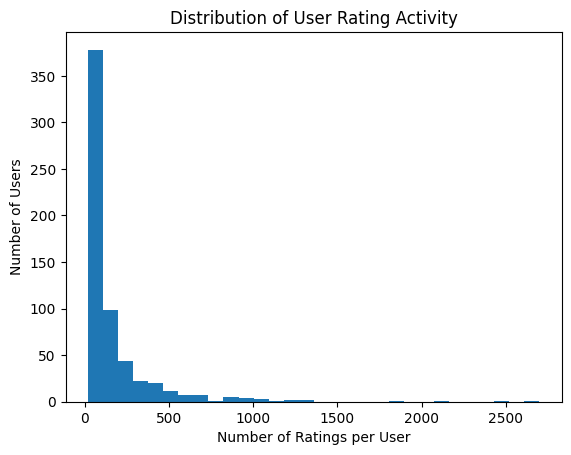

In [36]:
plt.hist(user_rating_counts["rating_count"], bins=30)

plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("Distribution of User Rating Activity")
plt.show()

## Rating Matrix Sparsity

Examine how many possible user-movie interactions are actually represented by ratings in the dataset.

In [37]:
num_users = ratings["userId"].nunique()
num_movies = ratings["movieId"].nunique()

possible_ratings = num_users * num_movies

possible_ratings #if all 610 users in the dataset had rated all 9,724 movies, hoe many total ratings would we have.

5931640

In [38]:
actual_ratings = len(ratings) # number of rows in the 'ratings' DataFrame.

actual_ratings #this is the actual number of ratings we have from the dataset

100836

In [39]:
density = actual_ratings / possible_ratings * 100

density #What percentage of all possible user-movie combinations actually have a rating?

1.6999683055613624

In [40]:
sparsity = 100 - density

sparsity #What percentage of possible user-movie combinations have no rating?

98.30003169443864

### Observation

The user-movie rating space is highly sparse. Only about 1.7% of all possible user-movie combinations contain a rating, while approximately 98.3% are unobserved. This is important for recommendation because the system must learn user preferences from a relatively small subset of possible interactions.

## Genre Distribution

Examine how frequently different genres appear across the movie catalog.

In [41]:
genre_counts = movies["genres"].str.split("|").explode().value_counts()
genre_counts

,count
genres,
Drama,4361
Comedy,3756
Thriller,1894
Action,1828
Romance,1596
Adventure,1263
Crime,1199
Sci-Fi,980
Horror,978


In [42]:
movies[movies["genres"] == "(no genres listed)"].head(10)

,movieId,title,genres
8517,114335,La cravate (1957),(no genres listed)
8684,122888,Ben-hur (2016),(no genres listed)
8687,122896,Pirates of the Caribbean: Dead Men Tell No Tal...,(no genres listed)
8782,129250,Superfast! (2015),(no genres listed)
8836,132084,Let It Be Me (1995),(no genres listed)
8902,134861,Trevor Noah: African American (2013),(no genres listed)
9033,141131,Guardians (2016),(no genres listed)
9053,141866,Green Room (2015),(no genres listed)
9070,142456,The Brand New Testament (2015),(no genres listed)
9091,143410,Hyena Road,(no genres listed)


In [43]:
no_genre_movies = movie_stats[
    movie_stats["genres"] == "(no genres listed)"
]

no_genre_movies.sort_values(
    "rating_count",
    ascending=False
).head(10)

,movieId,title,genres,rating_count,average_rating
8669,122896,Pirates of the Caribbean: Dead Men Tell No Tal...,(no genres listed),7,3.785714
9035,141866,Green Room (2015),(no genres listed),3,3.333333
9496,171495,Cosmos,(no genres listed),2,4.500000
9523,172591,The Godfather Trilogy: 1972-1990 (1992),(no genres listed),2,4.750000
9052,142456,The Brand New Testament (2015),(no genres listed),2,4.000000
9199,152037,Grease Live (2016),(no genres listed),2,2.000000
9408,166024,Whiplash (2013),(no genres listed),2,4.750000
8499,114335,La cravate (1957),(no genres listed),1,3.000000
8666,122888,Ben-hur (2016),(no genres listed),1,0.500000
8884,134861,Trevor Noah: African American (2013),(no genres listed),1,2.500000


In [44]:
movies_genres = movies.copy()
movies_genres["genre"] = movies_genres["genres"].str.split("|")
movies_genres.head()

,movieId,title,genres,genre
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),Comedy,[Comedy]


In [45]:
movies_genres = movies_genres.explode("genre") #turn CSV into rows
movies_genres.head(10)

,movieId,title,genres,genre
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Animation
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Children
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Comedy
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy,Adventure
1,2,Jumanji (1995),Adventure|Children|Fantasy,Children
1,2,Jumanji (1995),Adventure|Children|Fantasy,Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,Comedy
2,3,Grumpier Old Men (1995),Comedy|Romance,Romance


In [46]:
movie_genre_pairs = movies_genres[["movieId", "genre"]] #pick the relevant columns from our movies_genred DataFrame
movie_genre_pairs.head(10)

,movieId,genre
0,1,Adventure
0,1,Animation
0,1,Children
0,1,Comedy
0,1,Fantasy
1,2,Adventure
1,2,Children
1,2,Fantasy
2,3,Comedy
2,3,Romance


In [47]:
# merge the 'ratings' and 'movie_genres_pairs' DataFrames, and save into the new 'genre_ratings' DataFrame.

genre_ratings = ratings.merge(  # Start with the 'ratings' DataFrame and merge another DataFrame into it.
    movie_genre_pairs,          # This is the DataFrame we want to connect.
    on="movieId",               # Match rows where movieId is the same in both DataFrames.
    how="inner"                 # Keep only movieId values that exist in both DataFrames.
)

genre_ratings.head(10)

,userId,movieId,rating,timestamp,genre
0,1,1,4.0,964982703,Adventure
1,1,1,4.0,964982703,Animation
2,1,1,4.0,964982703,Children
3,1,1,4.0,964982703,Comedy
4,1,1,4.0,964982703,Fantasy
5,1,3,4.0,964981247,Comedy
6,1,3,4.0,964981247,Romance
7,1,6,4.0,964982224,Action
8,1,6,4.0,964982224,Crime
9,1,6,4.0,964982224,Thriller


In [48]:
genre_stats = genre_ratings.groupby("genre")["rating"].agg(
    ["mean", "count"]
)
genre_stats.sort_values(
    "mean",
    ascending=False
)

,mean,count
genre,,
Film-Noir,3.920115,870
War,3.808294,4859
Documentary,3.797785,1219
Crime,3.658294,16681
Drama,3.656184,41928
Mystery,3.632460,7674
Animation,3.629937,6988
IMAX,3.618335,4145
Western,3.583938,1930


### Average Rating by Genre

Visualize how average user ratings differ across movie genres.


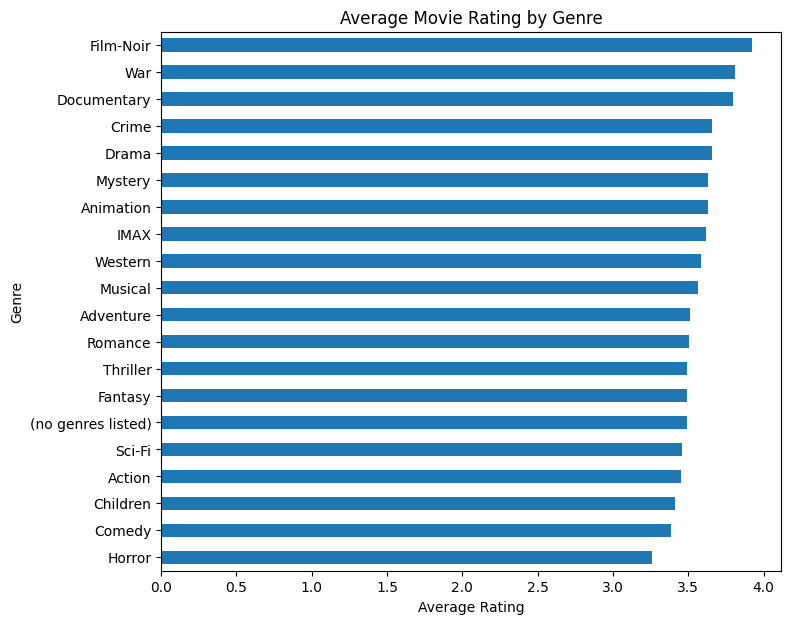

In [50]:
genre_stats.sort_values(
    "mean",
    ascending=True
)["mean"].plot(
    kind="barh",
    figsize=(8, 7)
)

plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.title("Average Movie Rating by Genre")
plt.show()

## EDA Summary

- MovieLens contains 100,836 ratings from 610 users.
- Ratings tend toward the higher end of the scale, with 4.0 being the most common rating.
- Movie popularity is highly uneven. Many movies have very few ratings, while a small number have hundreds.
- Requiring at least 10 ratings provided a more meaningful comparison of average movie ratings while retaining 2,269 movies.
- User activity is also highly uneven. The median user contributed about 70 ratings, while the most active user contributed 2,698.
- The user-movie interaction space is highly sparse: only about 1.7% of possible user-movie combinations contain a rating.
- Drama and Comedy are the most common genres, but genre prevalence does not necessarily correspond to higher average ratings.
- Average ratings across genres are relatively close, ranging roughly from 3.26 to 3.92.